<a href="https://colab.research.google.com/github/sirisunkavalli26/NeuraSectProj/blob/SiriBranch/Cifar10DataSetpython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving data_batch_1 to data_batch_1
Saving data_batch_2 to data_batch_2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display, clear_output

epochs = np.arange(1, 41)

training_loss = np.array(
    [2.30, 2.15, 2.05, 1.95, 1.85, 1.75, 1.68, 1.60, 1.55, 1.50] +
    list(1.48 - 0.01*np.arange(30) + 0.02*np.random.randn(30))
)

validation_loss = np.array(
    [2.30, 2.20, 2.15, 2.10, 2.05, 2.02, 2.00, 1.98, 1.97, 1.96] +
    list(1.95 - 0.005*np.arange(30) + 0.03*np.random.randn(30))
)

plt.ioff()
fig, ax = plt.subplots(figsize=(6, 4))

line_train, = ax.plot([], [], 's-', color='tab:blue', label='Training Loss')
line_val,   = ax.plot([], [], 'd-', color='tab:orange', label='Validation Loss')

ax.set_xlim(1, 40)
ax.set_ylim(1.0, 2.5)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("CIFAR-10 Training vs Validation Loss")
ax.grid(True)
ax.legend()

def init():
    line_train.set_data([], [])
    line_val.set_data([], [])
    return line_train, line_val

def update(frame):
    x = epochs[:frame+1]
    y_train = training_loss[:frame+1]
    y_val   = validation_loss[:frame+1]

    line_train.set_data(x, y_train)
    line_val.set_data(x, y_val)

    return line_train, line_val

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(epochs),
    init_func=init,
    blit=True,
    interval=150
)

clear_output(wait=True)
display(HTML(ani.to_jshtml()))


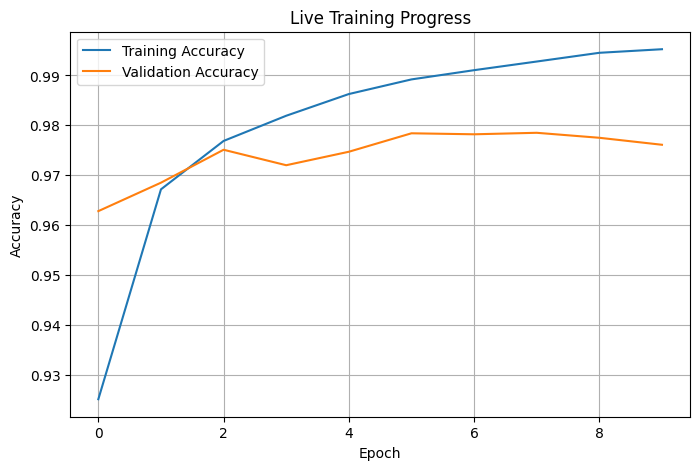

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from IPython.display import clear_output


class LiveAccuracyPlot(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.train_acc = []
        self.test_acc = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.train_acc.append(logs.get('accuracy'))
        self.test_acc.append(logs.get('val_accuracy'))

        clear_output(wait=True)
        plt.figure(figsize=(8, 5))
        plt.plot(self.train_acc, label="Training Accuracy")
        plt.plot(self.test_acc, label="Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Live Training Progress")
        plt.legend()
        plt.grid(True)
        plt.show()



(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28*28) / 255.0
x_test  = x_test.reshape(-1, 28*28) / 255.0

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    callbacks=[LiveAccuracyPlot()],
    verbose=0  # hide text logs, use only live plot
)
